In [1]:
from langgraph.graph import MessagesState
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [3]:
class ChatState(MessagesState):
    summary: str

In [4]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [5]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [6]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [7]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

In [8]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

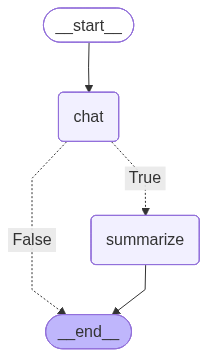

In [9]:
graph

In [10]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [11]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [12]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='cc656ead-1592-4cff-9137-41f158429eb1')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum Physics, also known as Quantum Mechanics, is a fundamental theory in phy


In [13]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='cc656ead-1592-4cff-9137-41f158429eb1'), AIMessage(content='Quantum Physics, also known as Quantum Mechanics, is a fundamental theory in physics that describes the behavior of matter and energy at the atomic and subatomic levels. It\'s one of the most successful and experimentally verified theories in science, yet its implications often challenge our classical intuitions about how the world works.\n\nHere\'s a breakdown of its core concepts and why it\'s so revolutionary:\n\n### Why is it "Quantum"?\n\nThe word "quantum" comes from the Latin word "quantus," meaning "how much." It refers to the idea that certain physical properties, like energy, come in discrete packets or "quanta," rather than continuous values. Imagine a ramp versus a staircase – classical physics sees a ramp (continuous values), while quantum physics sees a staircase (discrete steps).\n\n### Core Principles of Quantum Physics:\n\n

In [14]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='cc656ead-1592-4cff-9137-41f158429eb1'), AIMessage(content='Quantum Physics, also known as Quantum Mechanics, is a fundamental theory in physics that describes the behavior of matter and energy at the atomic and subatomic levels. It\'s one of the most successful and experimentally verified theories in science, yet its implications often challenge our classical intuitions about how the world works.\n\nHere\'s a breakdown of its core concepts and why it\'s so revolutionary:\n\n### Why is it "Quantum"?\n\nThe word "quantum" comes from the Latin word "quantus," meaning "how much." It refers to the idea that certain physical properties, like energy, come in discrete packets or "quanta," rather than continuous values. Imagine a ramp versus a staircase – classical physics sees a ramp (continuous values), while quantum physics sees a staircase (discrete steps).\n\n### Core Principles of Quantum Physics:\n\n

In [16]:
run_turn('Explain special theory of relativity in 200 words')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='cc656ead-1592-4cff-9137-41f158429eb1'), AIMessage(content='Quantum Physics, also known as Quantum Mechanics, is a fundamental theory in physics that describes the behavior of matter and energy at the atomic and subatomic levels. It\'s one of the most successful and experimentally verified theories in science, yet its implications often challenge our classical intuitions about how the world works.\n\nHere\'s a breakdown of its core concepts and why it\'s so revolutionary:\n\n### Why is it "Quantum"?\n\nThe word "quantum" comes from the Latin word "quantus," meaning "how much." It refers to the idea that certain physical properties, like energy, come in discrete packets or "quanta," rather than continuous values. Imagine a ramp versus a staircase – classical physics sees a ramp (continuous values), while quantum physics sees a staircase (discrete steps).\n\n### Core Principles of Quantum Physics:\n\n

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 29.439673965s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT